#1. Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import nltk
from nltk.corpus import stopwords

#2. Load the Dataset

In [20]:
df=pd.read_csv("/content/spam.csv", encoding="latin-1")
df=df[['v1', 'v2']]
df.columns=['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


#3. Checking and Cleaning Dataset

In [21]:
print("Dataset Shape: ", df.shape)

Dataset Shape:  (5572, 2)


In [22]:
df.isnull().sum()

,0
label,0
message,0


In [23]:
int(df.duplicated().sum())

403

In [24]:
df.drop_duplicates(inplace=True)

In [27]:
print("Dupliacte after cleaning:", int(df.duplicated().sum()))

Dupliacte after cleaning: 0


In [28]:
print("Dataset Shape after Cleaning:", df.shape)

Dataset Shape after Cleaning: (5169, 2)


#4. Class Distribution - Spam vs Ham

In [31]:
class_counts=df['label'].value_counts()
print("Class Counts:\n", class_counts)
class_precent=df['label'].value_counts(normalize=True)*100
print("\nClass Percentages:\n", class_precent.round(2))

Class Counts:
 label
ham     4516
spam     653
Name: count, dtype: int64

Class Percentages:
 label
ham     87.37
spam    12.63
Name: proportion, dtype: float64


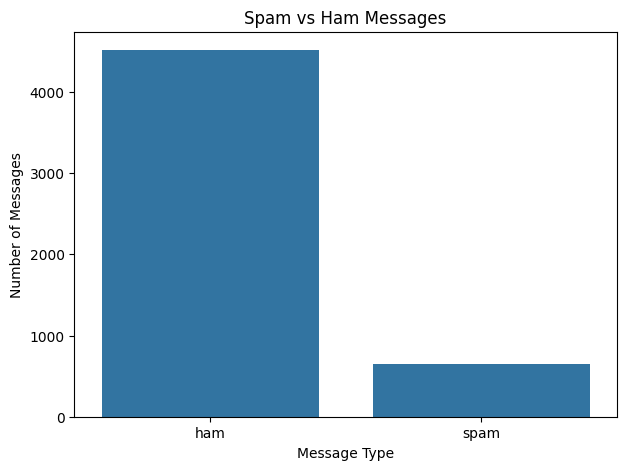

In [32]:
plt.figure(figsize=(7, 5))
sns.countplot(x='label', data=df)
plt.title('Spam vs Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')
plt.show()

#5. Download Stopwords

In [33]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

#6. Text Preprocessing

In [34]:
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)
df['clean_message'] = df['message'].apply(clean_text)
df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


#7. Convert Labels to Numbers

In [35]:
df['label_num'] = df['label'].map({
    'ham': 0,
    'spam': 1
})
df[['label', 'label_num']].head()

,label,label_num
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


#8. Train/Test Split

In [36]:
X = df['clean_message']
y = df['label_num']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


#9. TF-IDF Feature Extraction

In [37]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (4135, 5000)
Testing TF-IDF Shape: (1034, 5000)


### What is TF-IDF?

TF-IDF stands for Term Frequency-Inverse Document Frequency.

It measures how important a word is in a message compared with the whole collection of messages.

- TF measures how often a word appears in a message.
- IDF gives less importance to words that appear in many messages.
- Words that are common in one message but less common across the dataset receive higher TF-IDF scores.

TF-IDF converts text into numerical values that machine learning models can understand.

#10. Model 1 - Multinomial Naive Bayes

In [38]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_predictions = nb_model.predict(X_test_tfidf)

#11. Evaluate Naive Bayes

In [39]:
nb_accuracy = accuracy_score(y_test, nb_predictions)
nb_precision = precision_score(y_test, nb_predictions)
nb_recall = recall_score(y_test, nb_predictions)
nb_f1 = f1_score(y_test, nb_predictions)
print("Multinomial Naive Bayes:")
print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1 Score :", round(nb_f1, 4))

Multinomial Naive Bayes:
Accuracy : 0.9662
Precision: 0.9898
Recall   : 0.7405
F1 Score : 0.8472


#12. Naive Bayes Classification Report

In [40]:
print(classification_report(
    y_test,
    nb_predictions,
    target_names=['Ham', 'Spam']
))

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034



#13. Naive Bayes Confusion Matrix

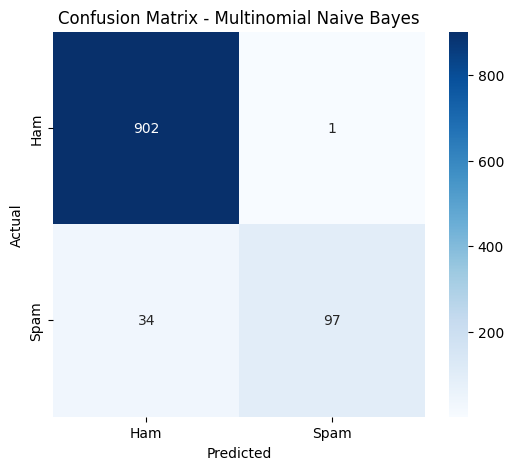

In [41]:
cm_nb = confusion_matrix(y_test, nb_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#14. Model 2 - Logistic Regression

In [42]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_predictions = lr_model.predict(X_test_tfidf)

#15. Evaluate Logistic Regression

In [43]:
lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)
print("Logistic Regression:")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))

Logistic Regression:
Accuracy : 0.9545
Precision: 0.9773
Recall   : 0.6565
F1 Score : 0.7854


#16. Logistic Regression Classification Report

In [44]:
print(classification_report(
    y_test,
    lr_predictions,
    target_names=['Ham', 'Spam']
))

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       903
        Spam       0.98      0.66      0.79       131

    accuracy                           0.95      1034
   macro avg       0.96      0.83      0.88      1034
weighted avg       0.96      0.95      0.95      1034



#17. Logistic Regression Confusion Matrix

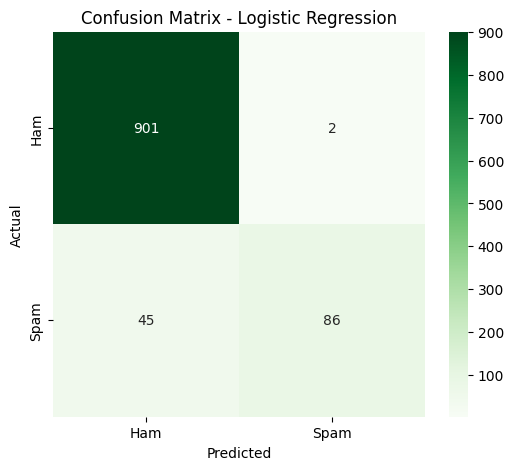

In [45]:
cm_lr = confusion_matrix(y_test, lr_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#18. Compare Both Models

In [47]:
results = pd.DataFrame({
    'Model': [
        'Multinomial Naive Bayes',
        'Logistic Regression'
    ],
    'Accuracy': [
        nb_accuracy,
        lr_accuracy
    ],
    'Precision': [
        nb_precision,
        lr_precision
    ],
    'Recall': [
        nb_recall,
        lr_recall
    ],
    'F1 Score': [
        nb_f1,
        lr_f1
    ]
})
print(results.round(4))

                     Model  Accuracy  Precision  Recall  F1 Score
0  Multinomial Naive Bayes    0.9662     0.9898  0.7405    0.8472
1      Logistic Regression    0.9545     0.9773  0.6565    0.7854


#19. Compare Model Performance Visually

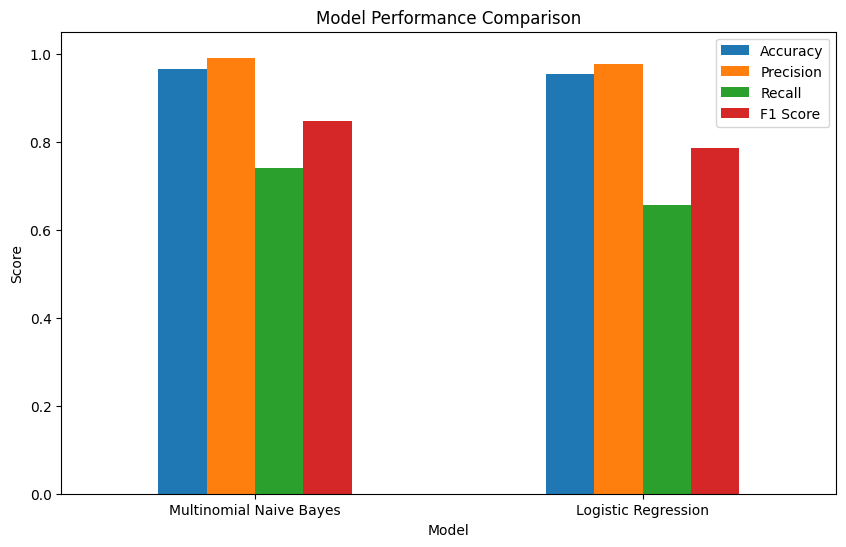

In [48]:
results_plot = results.set_index('Model')
results_plot.plot(
    kind='bar',
    figsize=(10, 6)
)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.show()

### Why is Recall Important for Spam Detection?

Recall is important because it tells us how many actual spam messages the model successfully detects.

If recall is low, many spam messages will be incorrectly classified as ham. These are called false negatives.

For example, if a user receives 100 actual spam messages and the model detects only 70, the recall is 70%.

A high recall means the model catches most of the spam messages. Therefore, recall is an important metric for spam detection.

#20. WordCloud for Spam Messages

In [49]:
from wordcloud import WordCloud

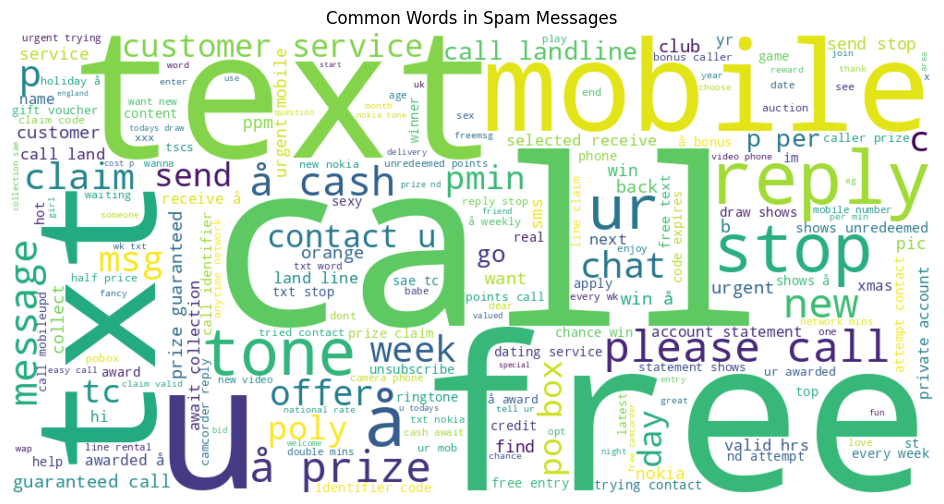

In [50]:
spam_text = ' '.join(
    df[df['label'] == 'spam']['clean_message']
)
spam_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(spam_text)
plt.figure(figsize=(12, 6))
plt.imshow(spam_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Spam Messages')
plt.show()

#21. WordCloud for Ham Messages

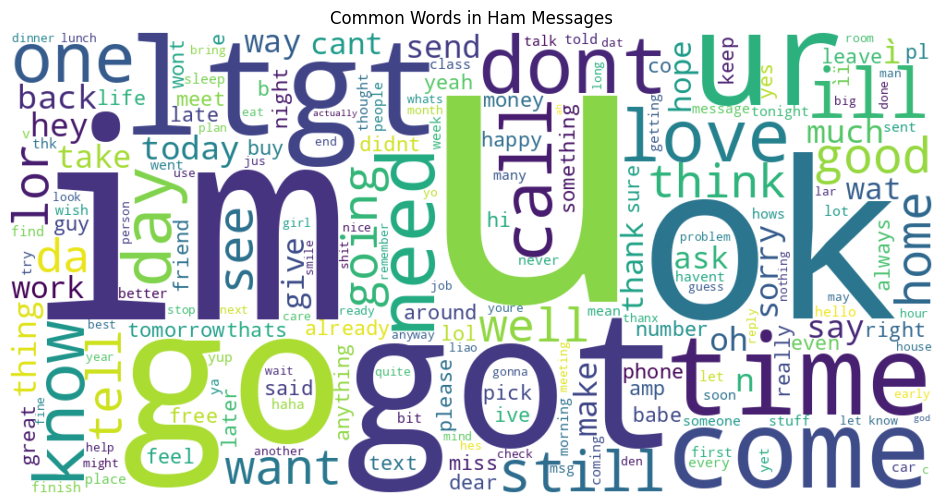

In [51]:
ham_text = ' '.join(
    df[df['label'] == 'ham']['clean_message']
)
ham_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(ham_text)
plt.figure(figsize=(12, 6))
plt.imshow(ham_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Ham Messages')
plt.show()